In [1]:
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Datasheet/credit_card_fraud_10k.csv'

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [3]:
df.head(5)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [5]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [7]:
df['is_fraud'].value_counts(normalize=True)*100

,proportion
is_fraud,
0,98.49
1,1.51


In [10]:
df.drop(columns='transaction_id', inplace=True)

In [11]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

**Feature Engineering**

In [12]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['transaction_hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['transaction_hour']/24)

In [13]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud', 'hour_sin',
       'hour_cos'],
      dtype='object')

**Preprocessing**

In [14]:
Feature = ['amount','hour_sin','hour_cos','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h','cardholder_age']
X = df[Feature]
y = df['is_fraud']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify=y)
print(f'Jumlah data training : {len(X_train)} dan jumlah data uji : {len(X_test)}')

Jumlah data training : 8000 dan jumlah data uji : 2000


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_feature = ['amount','device_trust_score','velocity_last_24h','cardholder_age']
num_transform = scaler

In [17]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_transform, num_feature)
], remainder = 'passthrough')

In [19]:
from sklearn.neighbors import KNeighborsClassifier

knn_baseline = KNeighborsClassifier()

**Model Baseline**

In [20]:
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', knn_baseline)
])

In [21]:
baseline_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model', KNeighborsClassifier())])

In [22]:
y_pred_baseline = baseline_pipeline.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
print(f'Akurasi Model Baseline : {accuracy_baseline:.4f}')
print(f'Precision Model Baseline : {precision_baseline:.4f}')
print(f'Recall Model Baseline : {recall_baseline:.4f}')
print(classification_report(y_test, y_pred_baseline))

Akurasi Model Baseline : 0.9875
Precision Model Baseline : 0.6471
Recall Model Baseline : 0.3667
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1970
           1       0.65      0.37      0.47        30

    accuracy                           0.99      2000
   macro avg       0.82      0.68      0.73      2000
weighted avg       0.99      0.99      0.99      2000



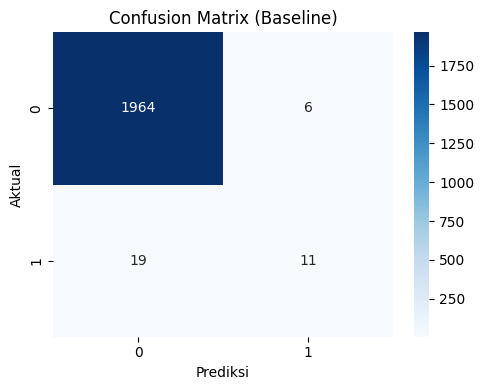

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [26]:
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:,1]
roc_auc_baseline = roc_auc_score(y_test, y_prob_baseline)
print(f"ROC AUC Score Baseline : {roc_auc_baseline:.4f}")

ROC AUC Score Baseline : 0.9270


**KNN + SMOTE**

In [27]:
from imblearn.pipeline import Pipeline as ImbLearnPipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = ImbLearnPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', knn_baseline)
])

In [28]:
smote_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', KNeighborsClassifier())])

In [29]:
y_pred_smote = smote_pipeline.predict(X_test)

In [30]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
print(f'Akurasi Model SMOTE : {accuracy_smote:.4f}')
print(f'Akurasi Precision SMOTE : {precision_smote:.4f}')
print(f'Akurasi Recall SMOTE : {recall_smote:.4f}')
print(classification_report(y_test, y_pred_smote))

Akurasi Model SMOTE : 0.9745
Akurasi Precision SMOTE : 0.3671
Akurasi Recall SMOTE : 0.9667
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      1970
           1       0.37      0.97      0.53        30

    accuracy                           0.97      2000
   macro avg       0.68      0.97      0.76      2000
weighted avg       0.99      0.97      0.98      2000



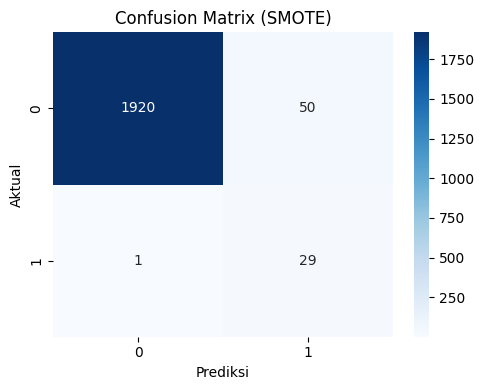

In [31]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SMOTE)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [33]:
y_prob_smote = smote_pipeline.predict_proba(X_test)[:,1]

In [34]:
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)
print(f"ROC AUC Score SMOTE : {roc_auc_smote:.4f}")

ROC AUC Score SMOTE : 0.9746


**Model Hyperparameter Tuning Menggunakan SMOTE**

In [46]:
params_grid = [
    {
    'model__n_neighbors': [ 1, 2, 3, 4, 5, 6, 7, 9, 11, 13, 15],
    'model__weights': ['uniform','distance'],
    'model__metric': ['euclidean', 'manhattan']
    },
     {
    'model__n_neighbors' : [ 1, 2, 3, 4, 5, 6, 7, 9, 11, 13, 15],
    'model__weights' : ['uniform','distance'],
    'model__metric' : ['minkowski'],
    'model__p' : [1,2]
    }
]

In [59]:
from sklearn.model_selection import GridSearchCV

grid_knn = GridSearchCV(
    estimator = smote_pipeline,
    param_grid = params_grid,
    cv= 5,
    scoring = 'f1',
    n_jobs = -1,
    verbose = 3
)

In [60]:
grid_knn.fit(X_train, y_train)

Fitting 5 folds for each of 88 candidates, totalling 440 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['amount',
                                                                          'device_trust_score',
                                                                          'velocity_last_24h',
                                                                          'cardholder_age'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid=[{'model__metric': ['euclidean', 'manhattan'],
                          'model__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 9, 11, 13,
                                                 15],
                          'model__weights': ['uniform', 'distance']},
                         {'model__metric': ['minkowski'],
                          'model__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 9, 11, 13,
                                                 15],
                          'model__p': [1, 2],
                          'model__weights': ['uniform', 'distance']}],
             scoring='f1', verbose=3)

In [61]:
print(grid_knn.best_params_)

{'model__metric': 'manhattan', 'model__n_neighbors': 4, 'model__weights': 'uniform'}


In [62]:
best_knn = grid_knn.best_estimator_

In [63]:
y_pred = best_knn.predict(X_test)

In [64]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'Akurasi Model : {accuracy:.4f}')
print(f'Precision Model : {precision:.4f}')
print(f'Recall Model : {recall:.4f}')
print(classification_report(y_test, y_pred))

Akurasi Model : 0.9810
Precision Model : 0.4310
Recall Model : 0.8333
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1970
           1       0.43      0.83      0.57        30

    accuracy                           0.98      2000
   macro avg       0.71      0.91      0.78      2000
weighted avg       0.99      0.98      0.98      2000



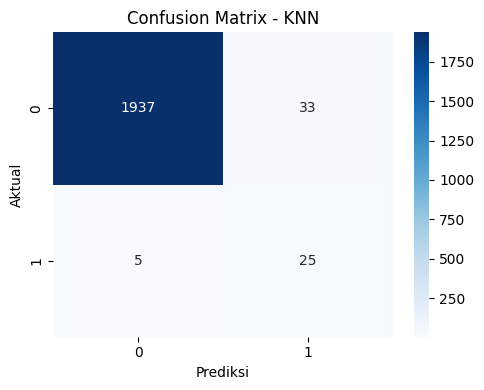

In [65]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [66]:
y_prob = best_knn.predict_proba(X_test)[:,1]

In [67]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score : {roc_auc:.4f}")

ROC AUC Score : 0.9582


In [68]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_knn,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=10,
    random_state=42,
    n_jobs = 1
)

In [70]:
feature_importance = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : result.importances_mean
})

In [71]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending = False
)

In [72]:
feature_importance

,Feature,Importance
5,device_trust_score,0.282800
3,foreign_transaction,0.241442
2,hour_cos,0.194061
4,location_mismatch,0.152953
1,hour_sin,0.089757
6,velocity_last_24h,0.076313
7,cardholder_age,0.009994
0,amount,-0.039835


/tmp/ipykernel_535/3112352673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


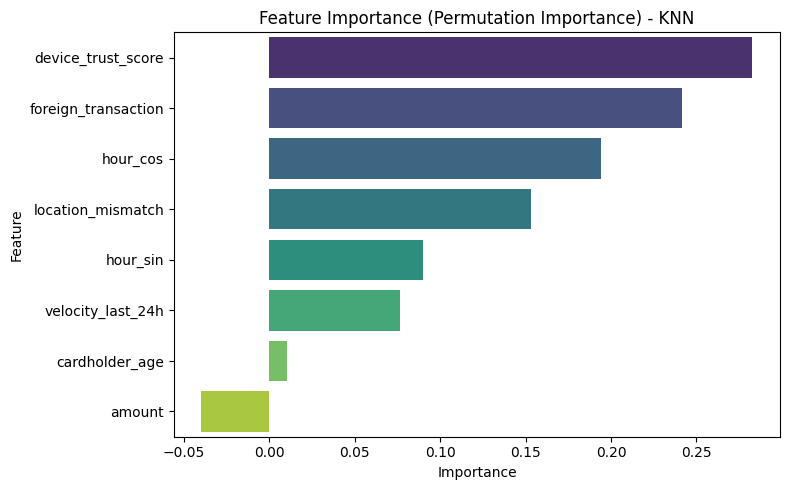

In [75]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette = 'viridis'
)
plt.title('Feature Importance (Permutation Importance) - KNN')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [76]:
import joblib
from google.colab import files

joblib.dump(best_knn,'K-Nearest_Neighbor.joblib')
files.download('K-Nearest_Neighbor.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>